# Presenting Game Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import requests
import seaborn as sns
import statsmodels

## Loading game result data

In [2]:
df = pd.read_csv("game-results.csv", parse_dates=True, header=None, names=["Game Version", "Date", "Time Survived", "Score"], dtype={"Game Version":"string","Time Survived":"float64","Score":"Int64"})

df = df.replace(r"^\s*$", pd.NA, regex=True)

df.set_index("Date", inplace=True)

## What data is stored and why
<hr>

### Game Version

Changes to the game may effect how scores are calculated or how much score a player get during a game.
As such we need the game version to group results by as to not make all results from a previous version effect results from a newer one.

### Date

This is the date time the results was set and is the id for each row.

### Time Survived

How long the run lasted in seconds

### Score


Checking the data is here

In [3]:
df.head()

,Game Version,Time Survived,Score
Date,,,
2026-08-11 22:02:53.976116,2026-08-10 23:55:20.054130,10.757392,260
2026-08-11 22:03:49.405594,2026-08-10 23:55:20.054130,24.408522,933
2026-08-11 22:07:52.788656,2026-08-10 23:55:20.054130,1.700332,31
2026-08-11 22:07:52.788656,2026-08-10 23:55:20.054130,1.700332,<NA>
2026-08-11 22:08:15.921228,2026-08-10 23:55:20.054130,NaN,340


In [4]:
df["Game Version"].unique()

<StringArray>
['2026-08-10 23:55:20.054130', <NA>, '2026-08-18 16:39:23.234698']
Length: 3, dtype: string

# Handling Empty Values
<hr>

All records missing a Date, Time Survived or Score are removed

If the Game Version is missing for a record it will check the previous record and next record. If the neighbouring records have the same Game Version fill the missing Game Version with their Game Version. Otherwise remove the record.

In [5]:
df = df.loc[df.index.dropna()]

df.dropna(subset=["Time Survived", "Score"], inplace=True)

df.head()

,Game Version,Time Survived,Score
Date,,,
2026-08-11 22:02:53.976116,2026-08-10 23:55:20.054130,10.757392,260
2026-08-11 22:03:49.405594,2026-08-10 23:55:20.054130,24.408522,933
2026-08-11 22:07:52.788656,2026-08-10 23:55:20.054130,1.700332,31
2026-08-11 22:07:52.788656,2026-08-10 23:55:20.054130,1.700332,31
2026-08-11 22:08:16.921228,2026-08-10 23:55:20.054130,12.781978,340


In [6]:
missing = df["Game Version"].isna()

for idx in df.index[missing]:
    pos = df.index.get_loc(idx)

    # First or Last
    if pos == 0 or pos == len(df) -1:
        df.drop(idx, inplace=True)
        continue

    above = df.iloc[pos -1]["Game Version"]
    below = df.iloc[pos + 1]["Game Version"]

    if pd.notna(above) and pd.notna(below) and above == below:
        df.at[idx, "Game Version"] = above
    else:
        df.drop(idx, inplace=True)
    

In [7]:
df["Game Version"].unique()

<StringArray>
['2026-08-10 23:55:20.054130', '2026-08-18 16:39:23.234698']
Length: 2, dtype: string

# Grouping Results by Game Version
<hr>

First as the game version's are a date they will be changed to a number in order of the game version's creation.

version_map is created incase the date the versions are created needs to be referenced in the future. e.g. if it is know the scoring wouldn't have been effected between 2 versions they could be remerged

In [8]:
version = pd.Series(df["Game Version"].unique()).sort_values().reset_index(drop=True)

version_map = pd.Series( version.values, index = range(1, len(version)+1))

df["Game Version"] = df["Game Version"].map(lambda x: version_map[version_map == x].index[0])

df.head()


,Game Version,Time Survived,Score
Date,,,
2026-08-11 22:02:53.976116,1,10.757392,260
2026-08-11 22:03:49.405594,1,24.408522,933
2026-08-11 22:07:52.788656,1,1.700332,31
2026-08-11 22:07:52.788656,1,1.700332,31
2026-08-11 22:08:16.921228,1,12.781978,340


In [9]:
version_map

1    2026-08-10 23:55:20.054130
2    2026-08-18 16:39:23.234698
dtype: string

Next a dictionary is created which will contain a dataframe of the Date, Time Survived and Score for each individual Game Version


In [10]:
dfs = {}

for version in df["Game Version"].unique():
    dfs[version] = df[df["Game Version"] == version][
        [ "Time Survived", "Score"]
    ].copy()

In [11]:
dfs

{np.int64(1):                             Time Survived  Score
 Date                                            
 2026-08-11 22:02:53.976116      10.757392    260
 2026-08-11 22:03:49.405594      24.408522    933
 2026-08-11 22:07:52.788656       1.700332     31
 2026-08-11 22:07:52.788656       1.700332     31
 2026-08-11 22:08:16.921228      12.781978    340
 2026-08-11 22:09:49.791919       0.995767     17
 2026-08-11 22:10:49.555555      10.995767     54
 2026-08-11 22:11:46.388839     107.160829  12791
 2026-08-11 22:18:21.849750       0.752936     13
 2026-08-11 22:47:28.879336      32.129955   1404
 2026-08-18 15:39:37.275915       4.388703     83,
 np.int64(2):                             Time Survived  Score
 Date                                            
 2026-08-18 16:39:55.994261      24.001978   1026
 2026-08-18 16:40:33.898785       0.443612      7
 2026-08-18 16:41:20.454644      30.065941   1503
 2026-08-18 22:21:20.366224      11.707017    324}

### Describe Each Game Version

In [12]:
for version, game_df in dfs.items():
    print(f"Game Version {version}, created {version_map[version]}")
    
    print("Score")
    print(game_df["Score"].describe())

    print("Time Survived")
    print(game_df["Time Survived"].describe())

Game Version 1, created 2026-08-10 23:55:20.054130
Score
count           11.0
mean     1450.636364
std      3788.125744
min             13.0
25%             31.0
50%             83.0
75%            636.5
max          12791.0
Name: Score, dtype: Float64
Time Survived
count     11.000000
mean      18.888410
std       31.005918
min        0.752936
25%        1.700332
50%       10.757392
75%       18.595250
max      107.160829
Name: Time Survived, dtype: float64
Game Version 2, created 2026-08-18 16:39:23.234698
Score
count           4.0
mean          715.0
std      676.217421
min             7.0
25%          244.75
50%           675.0
75%         1145.25
max          1503.0
Name: Score, dtype: Float64
Time Survived
count     4.000000
mean     16.554637
std      13.179312
min       0.443612
25%       8.891166
50%      17.854497
75%      25.517969
max      30.065941
Name: Time Survived, dtype: float64


# Grouping by Time Survived and Score
<hr>

In [13]:
time_bins = [0, 10, 30, 60, 90, float("inf")]
time_labels = ["< 10 seconds", "10–29 seconds", "30–59 seconds", "60-89 seconds", "90+ seconds"]

score_bins = [0, 100, 500, 1000, 5000, 10000, 50000, float("inf")]
score_labels = ["< 100 points", "100-499 points", "500-999 points", "1000-4999 points", "5000-9999 points", "10000-49999 points", ">50000 points"]

In [14]:
for version, game_df in dfs.items():
    game_df["Survival Group"] = pd.cut(game_df["Time Survived"], bins=time_bins, labels=time_labels, right=False)

    game_df["Points Group"] = pd.cut(game_df["Score"], bins=score_bins, labels=score_labels, right=False)


## Score per second

In [15]:
for version, game_df in dfs.items():
    game_df["Score per second"] = game_df["Score"] / game_df["Time Survived"]

In [16]:
dfs[1].head()

,Time Survived,Score,Survival Group,Points Group,Score per second
Date,,,,,
2026-08-11 22:02:53.976116,10.757392,260,10–29 seconds,100-499 points,24.169427
2026-08-11 22:03:49.405594,24.408522,933,10–29 seconds,500-999 points,38.224355
2026-08-11 22:07:52.788656,1.700332,31,< 10 seconds,< 100 points,18.231729
2026-08-11 22:07:52.788656,1.700332,31,< 10 seconds,< 100 points,18.231729
2026-08-11 22:08:16.921228,12.781978,340,10–29 seconds,100-499 points,26.599951


# Creating Graphs
<hr>

### Score over time
<hr>
Removing the top and bottom 2.5% Scores then plotting Score vs Time Survived for Game Version 1

In [17]:
gv1_df = dfs[1][(
    (dfs[1]["Score"] >= dfs[1]["Score"].quantile(0.025)) &
    (dfs[1]["Score"] <= dfs[1]["Score"].quantile(0.975)))]

C:\Users\jhinc\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


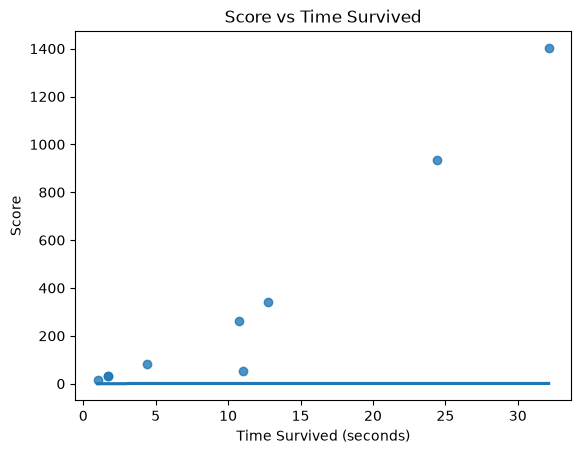

In [18]:
sns.regplot(data=gv1_df, x="Time Survived", y="Score", logistic=True, ci=None)
plt.xlabel("Time Survived (seconds)")
plt.ylabel("Score")
plt.title("Score vs Time Survived")
plt.show()

## Displaying the Survival Groups and Points Groups for a specific Game Version
<hr>

In [19]:
def bar_charts(game_version:int):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    fig.suptitle(f"Game Results for Game Version {game_version}", fontsize=16,fontweight="bold")
    
    # Survival Group
    sns.countplot(
        data=dfs[game_version],
        x="Survival Group",
        ax=axes[0]
    )
    axes[0].set_xlabel("Survival Group")
    axes[0].set_ylabel("Number of Results")
    axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].set_title("Results by Survival Group")
    axes[0].tick_params(axis="x", rotation=45)

    # Points Group
    sns.countplot(
        data=dfs[game_version],
        x="Points Group",
        ax=axes[1]
    )
    axes[1].set_xlabel("Points Group")
    axes[1].set_ylabel("Number of Results")
    axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].set_title("Results by Points Group")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

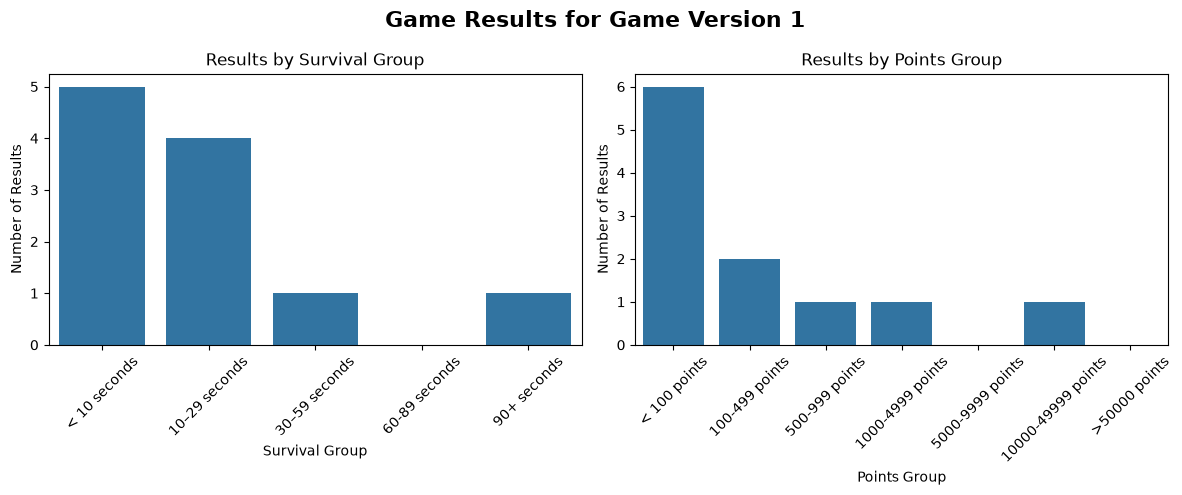

In [20]:
bar_charts(1)

### Graphs of each Game Version

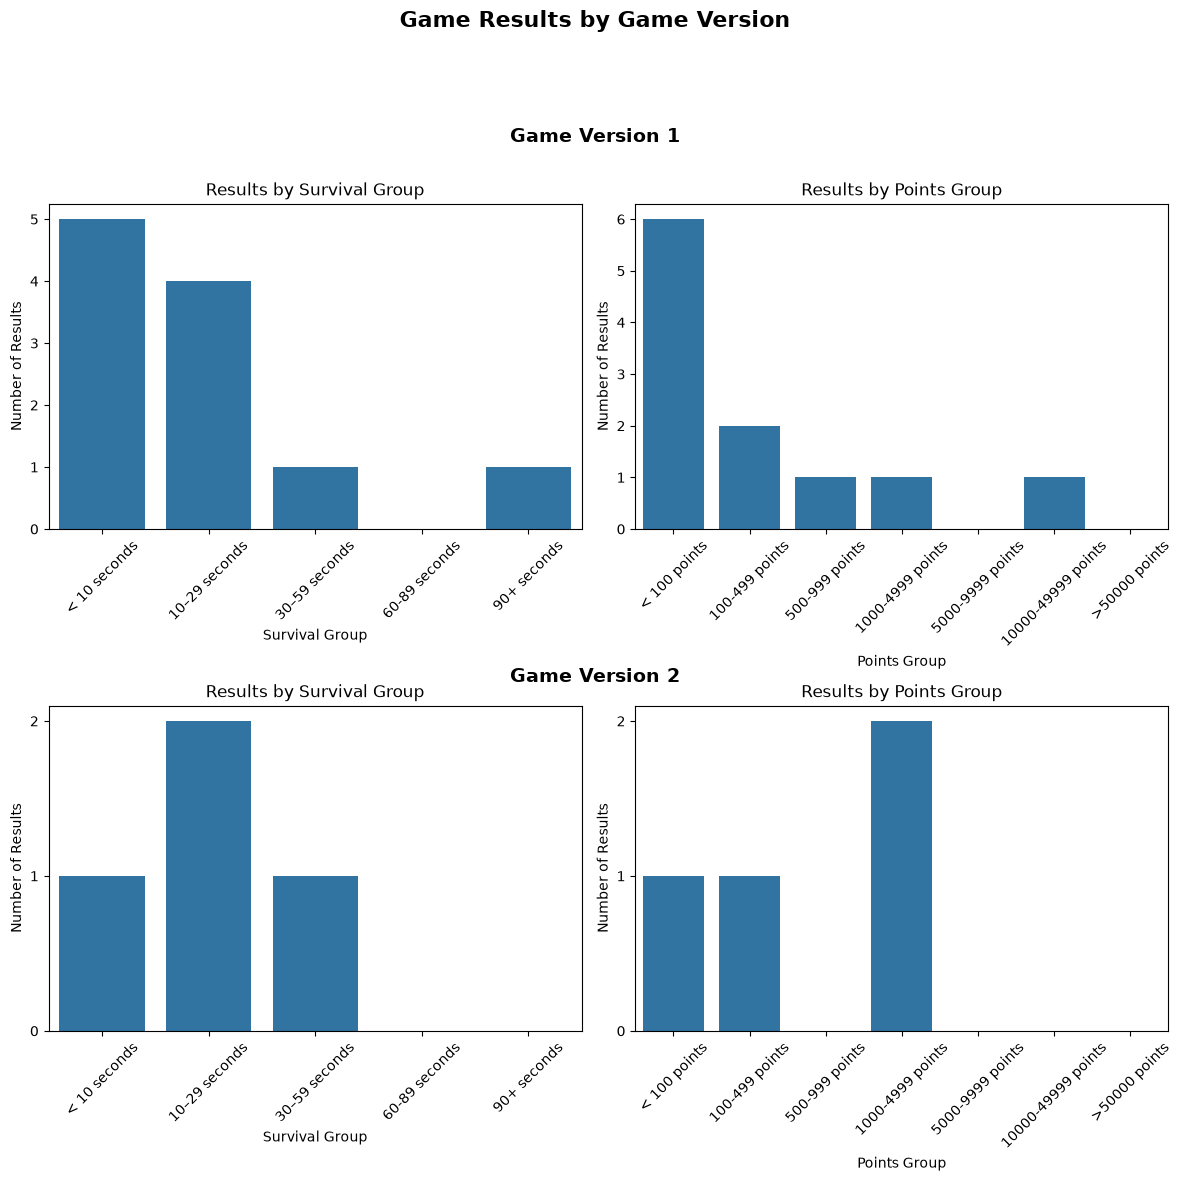

In [21]:
fig, axes = plt.subplots(len(dfs), 2, figsize=(12, 6*len(dfs)))

fig.suptitle("Game Results by Game Version", fontsize=16,fontweight="bold")

for row, (version, game_df) in enumerate(dfs.items()):

    # Survival Group
    sns.countplot(
        data=game_df,
        x="Survival Group",
        ax=axes[row, 0]
    )
    axes[row, 0].set_xlabel("Survival Group")
    axes[row, 0].set_ylabel("Number of Results")
    axes[row, 0].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes[row, 0].set_title("Results by Survival Group")
    axes[row, 0].tick_params(axis="x", rotation=45)

    # Points Group
    sns.countplot(
        data=game_df,
        x="Points Group",
        ax=axes[row, 1]
    )
    axes[row, 1].set_xlabel("Points Group")
    axes[row, 1].set_ylabel("Number of Results")
    axes[row, 1].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes[row, 1].set_title("Results by Points Group")
    axes[row, 1].tick_params(axis="x", rotation=45)

    y_position = 0.87 - row * (.9 / len(dfs))
    
    # Game Version above the row
    fig.text(
        0.5,
        y_position,
        f"Game Version {version}",
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()
    